# Задание 1. Анализ и подготовка временного ряда

In [20]:
!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install statsmodels
!pip install scikit-learn
!pip install pmdarima

   ---------------------------------------- 0.0/715.6 kB ? eta -:--:--
   ---------------------------------------- 0.0/715.6 kB ? eta -:--:--
   ---------------------------------------- 0.0/715.6 kB ? eta -:--:--
   ---------------------------------------- 0.0/715.6 kB ? eta -:--:--
   ---------------------------------------- 0.0/715.6 kB ? eta -:--:--
   ---------------------------------------- 715.6/715.6 kB 5.8 MB/s  0:00:00
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ----------- ---------------------------- 0.8/2.8 MB 8.3 MB/s eta 0:00:01
   ----------- ---------------------------- 0.8/2.8 MB 8.3 MB/s eta 0:00:01
   ----------- ---------------------------- 0.8/2.8 MB 8.3 MB/s eta 0:00:01
   ----------- ---------------------------- 0.8/2.8 MB 8.3 MB/s eta 0:00:01
   ------------------ --------------------- 1.3/2.8 MB 1.2 MB/s eta 0:00:02
   ---------------------- ----------------- 1.6/2.8 MB 1.2 MB/s eta 0:00:01
   ---------------------- -----------------

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from scipy.stats import boxcox

plt.style.use('seaborn-v0_8')
sns.set_theme(style="whitegrid")

df = pd.read_csv('../data/PJME_hourly.csv', sep=',')
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.sort_values('Datetime')

df.set_index('Datetime', inplace=True)

print(f"Дубликатов индекса: {df.index.duplicated().sum()}")
df = df[~df.index.duplicated(keep='first')]
print(f"Дубликатов после удаления: {df.index.duplicated().sum()}")
print(df.head())
print(df.info())

Дубликатов индекса: 4
Дубликатов после удаления: 0
                     PJME_MW
Datetime                    
2002-01-01 01:00:00  30393.0
2002-01-01 02:00:00  29265.0
2002-01-01 03:00:00  28357.0
2002-01-01 04:00:00  27899.0
2002-01-01 05:00:00  28057.0
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 145362 entries, 2002-01-01 01:00:00 to 2018-08-03 00:00:00
Data columns (total 1 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   PJME_MW  145362 non-null  float64
dtypes: float64(1)
memory usage: 6.2 MB
None


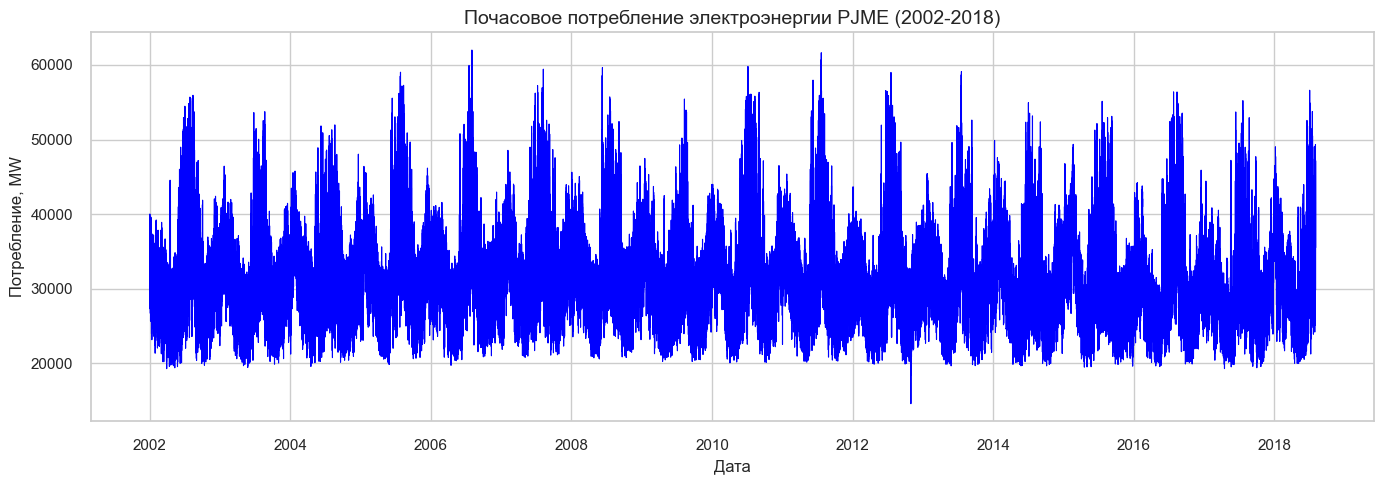

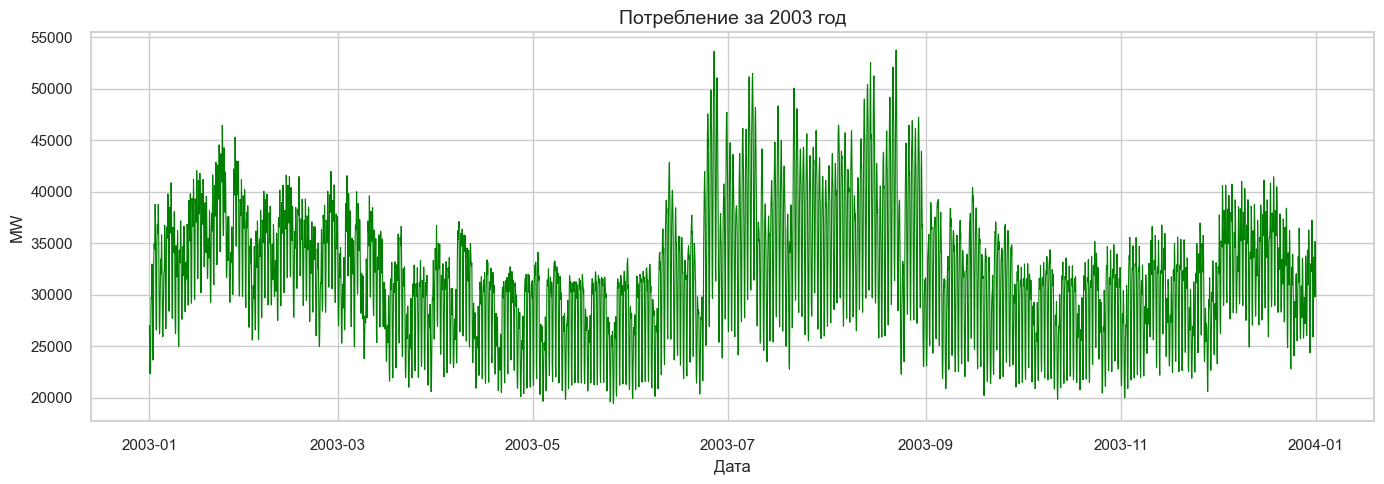

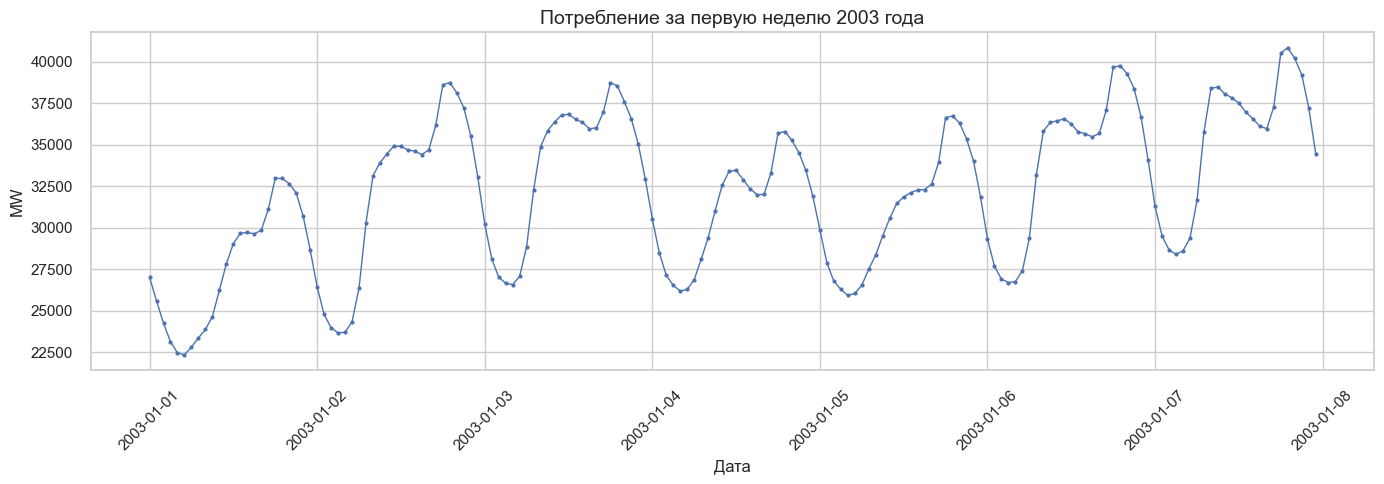

In [3]:
plt.figure(figsize=(14, 5))
plt.plot(df.index, df['PJME_MW'], color='blue', linewidth=0.8)
plt.title('Почасовое потребление электроэнергии PJME (2002-2018)', fontsize=14)
plt.xlabel('Дата')
plt.ylabel('Потребление, MW')
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(df.loc['2003'].index, df.loc['2003']['PJME_MW'], color='green', linewidth=0.8)
plt.title('Потребление за 2003 год', fontsize=14)
plt.xlabel('Дата')
plt.ylabel('MW')
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(df.loc['2003-01-01':'2003-01-07'].index, 
         df.loc['2003-01-01':'2003-01-07']['PJME_MW'], 
         marker='o', markersize=3, linewidth=1)
plt.title('Потребление за первую неделю 2003 года', fontsize=14)
plt.xlabel('Дата')
plt.ylabel('MW')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Тренд: Отсутствует или слабый  

Сезонность:
Суточная: Вечерний пок и спад на ночь
Годовая: зимой выше за счет отопления, летом выше за счет кондиционеров, весной/осенью ниже.
Выбросы: Есть несколько заметных разовыхпиков и просадок, в целом по данным наблюдается шум

In [4]:
def adf_test(series, title=''):
    """
    Выводит результаты теста ADF
    """
    result = adfuller(series, autolag='AIC')
    print(f'Результаты теста ADF для {title}:')
    print(f'ADF статистика: {result[0]:.6f}')
    print(f'p-value: {result[1]:.6f}')
    print(f'Критические значения:')
    for key, value in result[4].items():
        print(f'   {key}: {value:.3f}')
    if result[1] <= 0.05:
        print("=> Ряд стационарен (отвергаем H0)\n")
    else:
        print("=> Ряд НЕ стационарен (не отвергаем H0)\n")
    return result[1]

p_orig = adf_test(df['PJME_MW'], 'исходного ряда')

Результаты теста ADF для исходного ряда:
ADF статистика: -19.885450
p-value: 0.000000
Критические значения:
   1%: -3.430
   5%: -2.862
   10%: -2.567
=> Ряд стационарен (отвергаем H0)



Тест ADF называет ряд стационарным. Сезонность ряда постоянная, десперсия стабильная, а тренда нет. Проведем сезонное дифференцирования для сглаживания суточной сезонности для ARIMA.

In [5]:
series_seasonal_diff = df['PJME_MW'].diff(24)
series_seasonal_diff_clean = series_seasonal_diff.dropna()
p_seasonal = adf_test(series_seasonal_diff_clean, "После сезонного дифференцирования (лаг 24)")

df['stationary_for_ARIMA'] = series_seasonal_diff

Результаты теста ADF для После сезонного дифференцирования (лаг 24):
ADF статистика: -51.462079
p-value: 0.000000
Критические значения:
   1%: -3.430
   5%: -2.862
   10%: -2.567
=> Ряд стационарен (отвергаем H0)



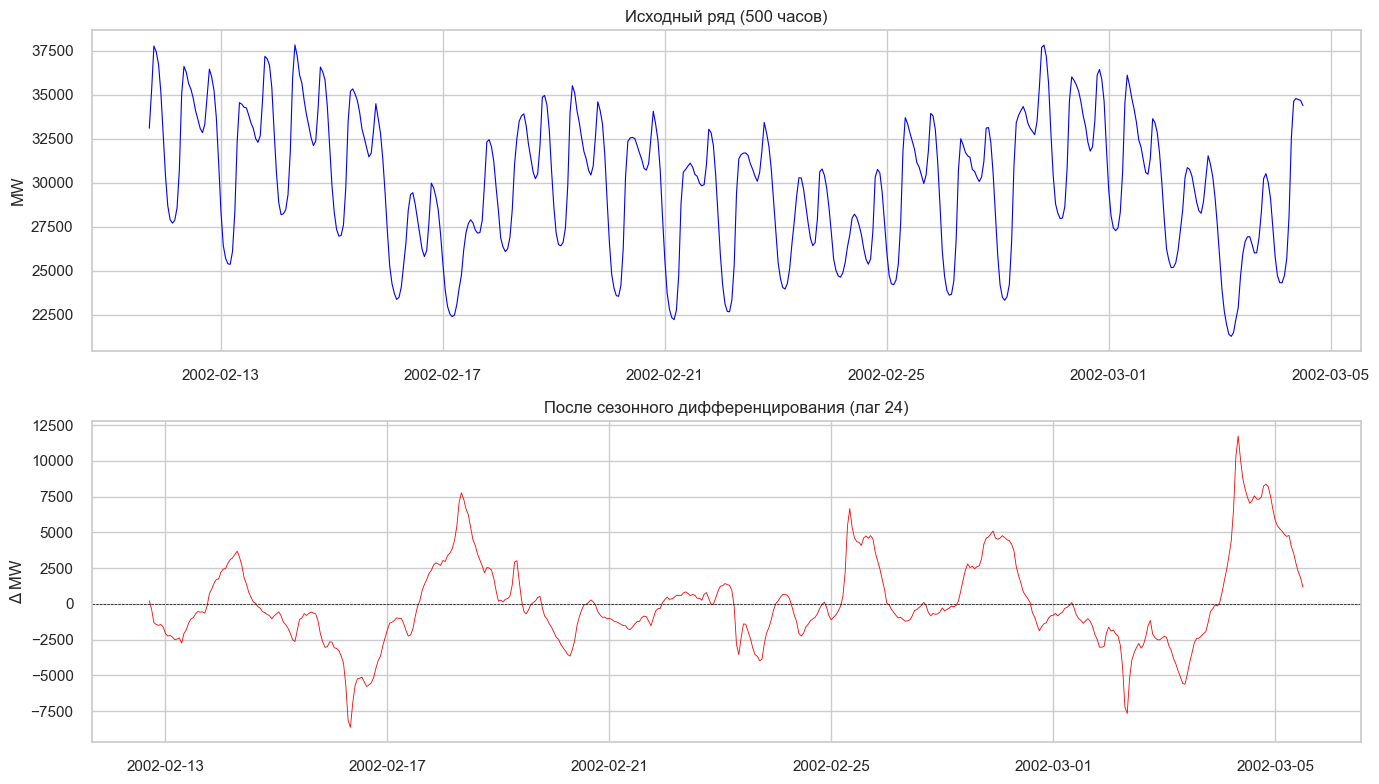

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Исходный ряд (первые 500 часов)
axes[0].plot(df['PJME_MW'][1000:1500], color='blue', linewidth=0.8)
axes[0].set_title('Исходный ряд (500 часов)')
axes[0].set_ylabel('MW')
axes[0].grid(True)

# После сезонного дифференцирования
axes[1].plot(series_seasonal_diff_clean[1000:1500], color='red', linewidth=0.6)
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=0.5)
axes[1].set_title('После сезонного дифференцирования (лаг 24)')
axes[1].set_ylabel('Δ MW')
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Задание 2. Базовая ARIMA-модель

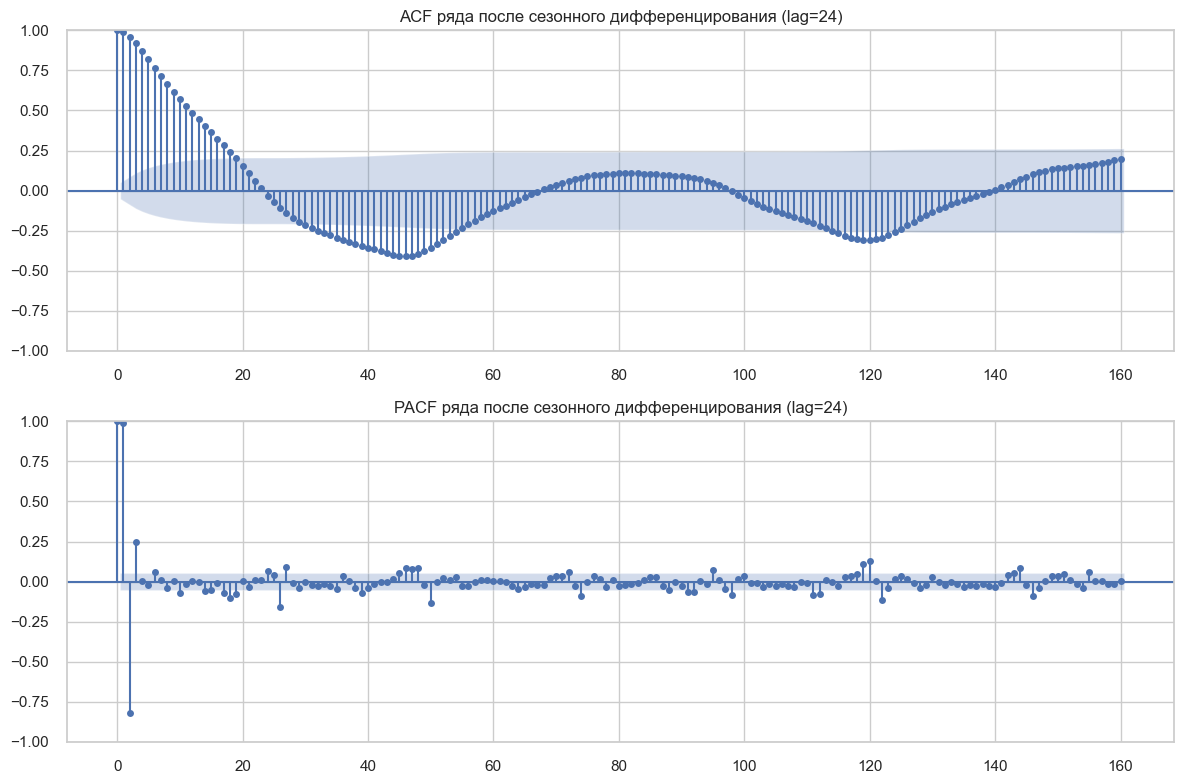

                               SARIMAX Results                                
Dep. Variable:                PJME_MW   No. Observations:                 1488
Model:                 ARIMA(4, 0, 0)   Log Likelihood              -10708.504
Date:                Sun, 24 May 2026   AIC                          21429.008
Time:                        17:17:13   BIC                          21460.839
Sample:                    05-26-2018   HQIC                         21440.871
                         - 07-27-2018                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        101.3952    616.978      0.164      0.869   -1107.860    1310.650
ar.L1          2.1511      0.016    132.554      0.000       2.119       2.183
ar.L2         -1.6062      0.041    -39.396      0.0

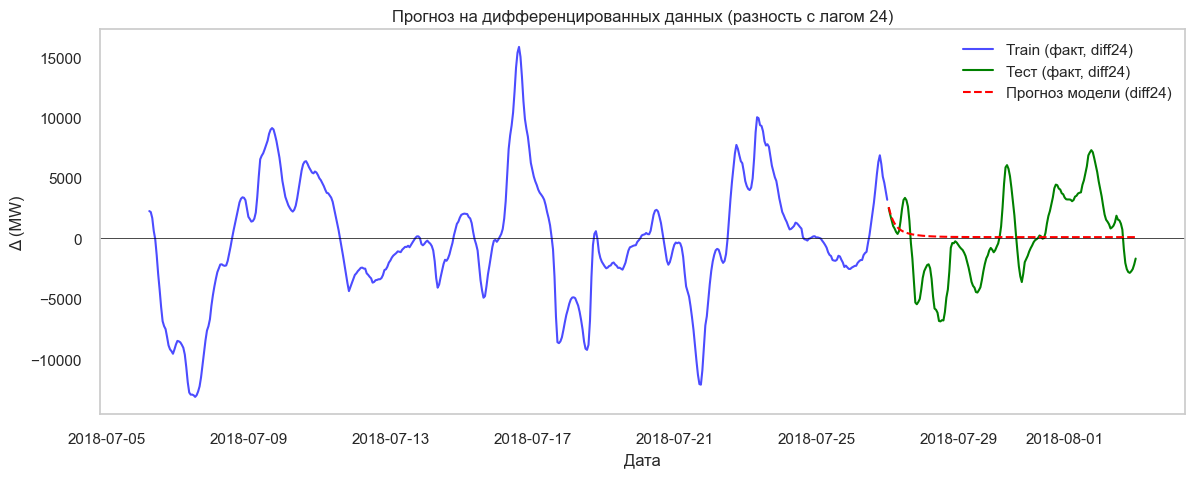

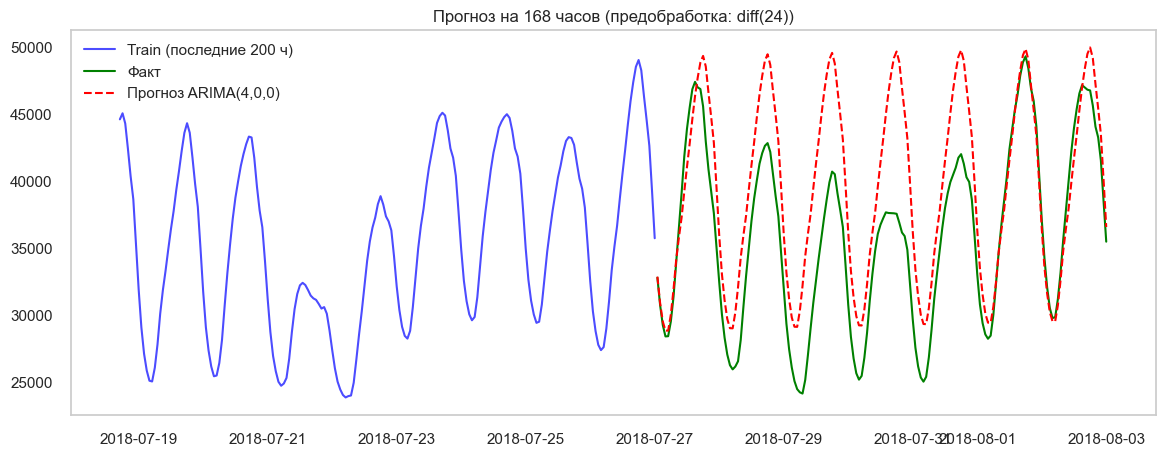

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
from statsmodels.stats.diagnostic import acorr_ljungbox
import warnings
warnings.filterwarnings('ignore')

test_hours = 168
train = df.iloc[-test_hours*10:-test_hours].copy()
test = df.iloc[-test_hours:].copy()

train_stationary = train['PJME_MW'].diff(24).dropna()
test_stationary = df.iloc[-test_hours-24:].copy()['PJME_MW'].diff(24).dropna()

# Построение ACF и PACF для стационарного ряда
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(train_stationary, lags=160, ax=ax1)
plot_pacf(train_stationary, lags=160, ax=ax2, method='ywm')
ax1.set_title('ACF ряда после сезонного дифференцирования (lag=24)')
ax2.set_title('PACF ряда после сезонного дифференцирования (lag=24)')
plt.tight_layout()
plt.show()

# Ручной подбор параметров:
# PACF обрывается после лага 4 → p=4
# ACF затухает → q=0
# d=0, так как ряд уже стационарный
p, q = 4, 0
model = ARIMA(train_stationary, order=(p, 0, q))
fitted = model.fit()
print(fitted.summary())

forecast_stationary = fitted.forecast(steps=test_hours)

# Восстановление прогноза исходного ряда
# Для diff(24): Y_{t} = Y_{t-24} + разность
last_24 = train['PJME_MW'].iloc[-24:].values
forecast_original = []
for i, diff_pred in enumerate(forecast_stationary):
    if i < 24:
        new_val = last_24[i] + diff_pred
    else:
        new_val = forecast_original[i-24] + diff_pred
    forecast_original.append(new_val)

forecast_original = pd.Series(forecast_original, index=test.index)

# Оценка качества на исходном ряде
y_true = test['PJME_MW']
y_pred = forecast_original
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print(f"\nОценка качества на тесте (168 часов):")
print(f"RMSE = {rmse:.2f} MW")
print(f"MAPE = {mape:.2f}%")

horizons = [1, 6, 24, 48, 168]
print("\nКачество на разных горизонтах:")
for h in horizons:
    y_true_h = y_true[:h]
    y_pred_h = forecast_original[:h]
    rmse_h = np.sqrt(mean_squared_error(y_true_h, y_pred_h))
    mape_h = np.mean(np.abs((y_true_h - y_pred_h) / y_true_h)) * 100
    print(f"  Горизонт {h:3d} ч: RMSE={rmse_h:6.0f} MW, MAPE={mape_h:5.2f}%")

plt.figure(figsize=(14, 5))

plt.plot(train_stationary.index[-500:], train_stationary.iloc[-500:], 
         label='Train (факт, diff24)', color='blue', alpha=0.7)
plt.plot(test_stationary.index, test_stationary, 
         label='Тест (факт, diff24)', color='green', linewidth=1.5)
plt.plot(test.index, forecast_stationary, 
         label='Прогноз модели (diff24)', color='red', linestyle='--', linewidth=1.5)

plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
plt.title('Прогноз на дифференцированных данных (разность с лагом 24)')
plt.xlabel('Дата')
plt.ylabel('Δ (MW)')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(14,5))
plt.plot(train.index[-200:], train['PJME_MW'].iloc[-200:], 
         label='Train (последние 200 ч)', color='blue', alpha=0.7)
plt.plot(test.index, y_true, label='Факт', color='green')
plt.plot(test.index, forecast_original, label=f'Прогноз ARIMA({p},0,{q})', 
         color='red', linestyle='--')
plt.title(f'Прогноз на {test_hours} часов (предобработка: diff(24))')
plt.legend()
plt.grid()
plt.show()

# Задание 3. Диагностика модели

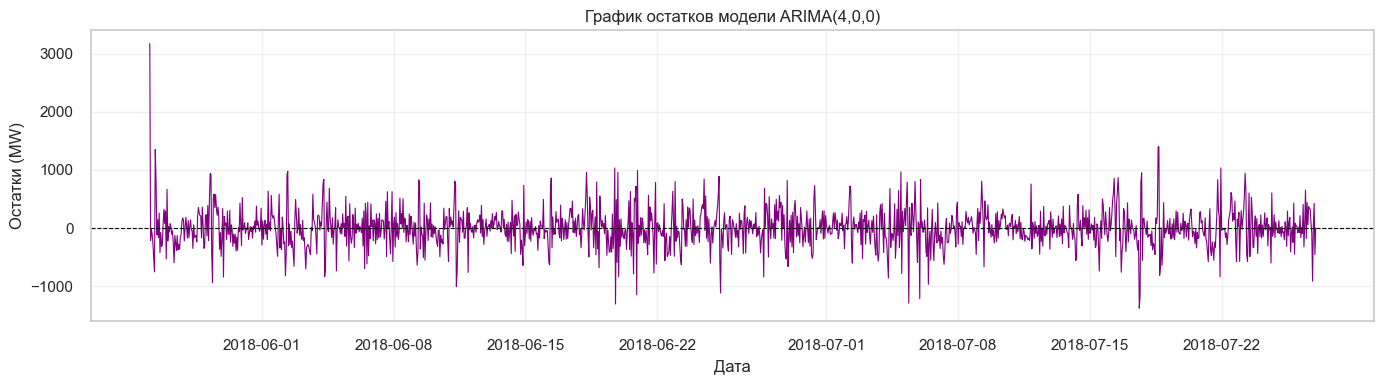

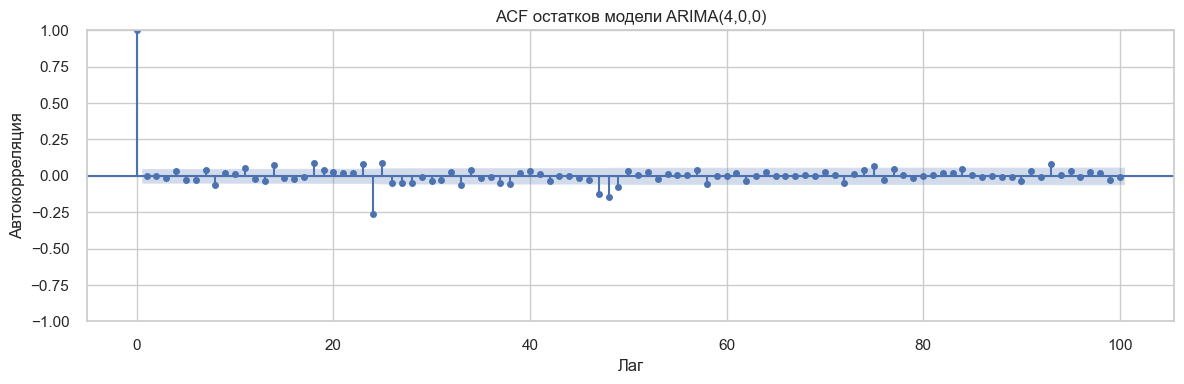

Тест Льюнга-Бокса для остатков
       lb_stat     lb_pvalue
10   14.082852  1.692459e-01
20   44.537826  1.274240e-03
30  183.756133  5.167071e-24
40  205.759146  3.602988e-24
50  276.623471  3.998298e-33
На лагах [20, 30, 40, 50] p-value < 0.05. Остатки коррелированы (есть зависимость, не учтённая моделью)

Модель нельзя считать адекватной.
Текущая модель ARIMA(4,0,0) неадекватна из-за корреляции остатков. Можно попробовать увеличить p. Добавлять составляющую q нет смысла, т.к. ACF остаткой затухает быстро. В данных большое значение сезонностей, более целесообразно использовать SARIMA.


In [10]:
residuals = fitted.resid  # остатки модели ARIMA(4,0,0) на стационарном ряду

plt.figure(figsize=(14, 4))
plt.plot(residuals, color='purple', linewidth=0.8)
plt.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
plt.title('График остатков модели ARIMA(4,0,0)', fontsize=12)
plt.xlabel('Дата')
plt.ylabel('Остатки (MW)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
plot_acf(residuals, lags=100, ax=ax)
ax.set_title('ACF остатков модели ARIMA(4,0,0)', fontsize=12)
ax.set_xlabel('Лаг')
ax.set_ylabel('Автокорреляция')
plt.tight_layout()
plt.show()

# Тест Льюнга-Бокса 
from statsmodels.stats.diagnostic import acorr_ljungbox

lb_test = acorr_ljungbox(residuals, lags=[10, 20, 30, 40, 50], return_df=True)
print("Тест Льюнга-Бокса для остатков")
print(lb_test.to_string())

significant_lags = lb_test[lb_test['lb_pvalue'] < 0.05]
if len(significant_lags) > 0:
    print(f"На лагах {list(significant_lags.index)} p-value < 0.05. Остатки коррелированы (есть зависимость, не учтённая моделью)")
    print("\nМодель нельзя считать адекватной.")
else:
    print("На всех проверенных лагах p-value >= 0.05. Остатки некоррелированы (белый шум)")
    print("\nМодель можно считать адекватной.")

print("Текущая модель ARIMA(4,0,0) неадекватна из-за корреляции остатков. Можно попробовать увеличить p. Добавлять составляющую q нет смысла, т.к. ACF остаткой затухает быстро. В данных большое значение сезонностей, более целесообразно использовать SARIMA.")

Анализ улучшения модели

  p | Адекватна  | Знач.лагов |    RMSE (MW) |   MAPE (%) |      ΔRMSE |      ΔMAPE
  5 |    Нет     |     4      |      4992.94 |      11.72 |     -36.99 |      -0.09
  6 |    Нет     |     4      |      5247.54 |      12.34 |    +254.61 |      +0.62
  7 |    Нет     |     4      |      5186.67 |      12.21 |     -60.87 |      -0.13
  8 |    Нет     |     4      |      5217.18 |      12.28 |     +30.51 |      +0.07
  9 |    Нет     |     4      |      5178.85 |      12.20 |     -38.33 |      -0.08
 10 |    Нет     |     4      |      4953.38 |      11.72 |    -225.47 |      -0.48
 11 |    Нет     |     4      |      4996.97 |      11.82 |     +43.59 |      +0.10
 12 |    Нет     |     4      |      4963.95 |      11.74 |     -33.02 |      -0.08
 13 |    Нет     |     4      |      4972.90 |      11.76 |      +8.95 |      +0.02
 14 |    Нет     |     3      |      4863.81 |      11.46 |    -109.10 |      -0.30
 15 |    Нет     |     3      |      4844.14 |     

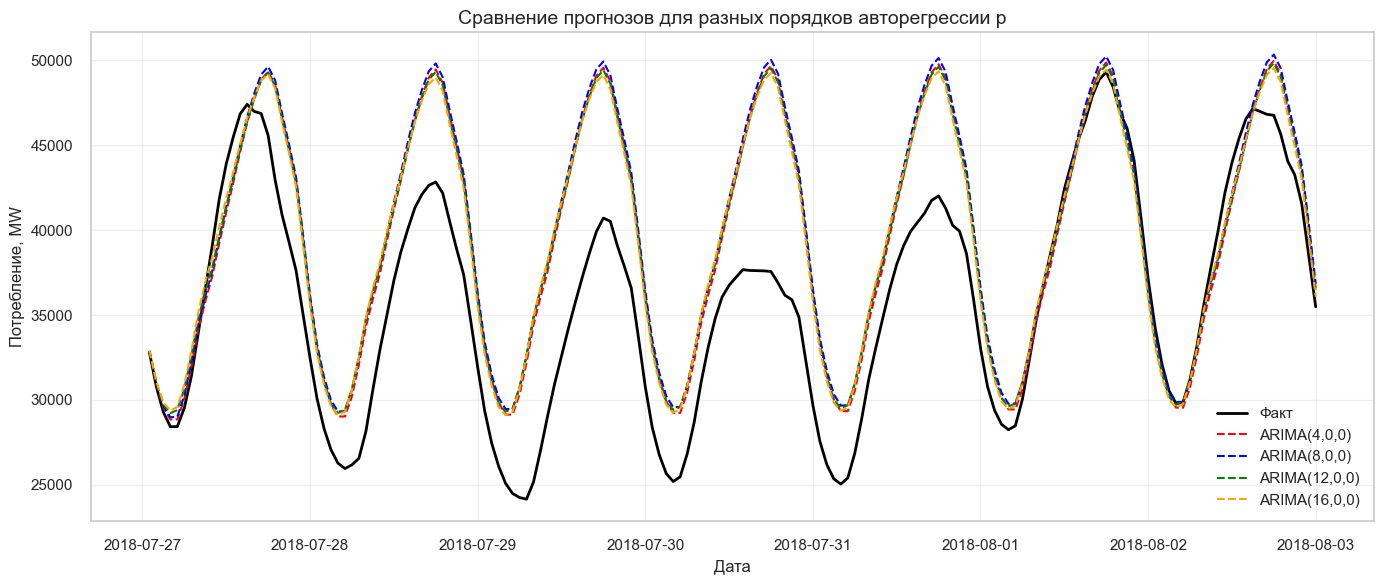

In [11]:
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_squared_error

print("Анализ улучшения модели")

results_p = {}
def inverse_diff(forecast_diff, last_24_values):
    forecast_original = []
    for i, diff_pred in enumerate(forecast_diff):
        if i < 24:
            new_val = last_24_values[i] + diff_pred
        else:
            new_val = forecast_original[i-24] + diff_pred
        forecast_original.append(new_val)
    return forecast_original

last_24 = train['PJME_MW'].iloc[-24:].values
y_true = test['PJME_MW'].values

forecast_p4_diff = fitted.forecast(steps=test_hours)
forecast_p4_orig = inverse_diff(forecast_p4_diff, last_24)
rmse_p4 = np.sqrt(mean_squared_error(y_true, forecast_p4_orig))
mape_p4 = np.mean(np.abs((y_true - forecast_p4_orig) / y_true)) * 100

results_p[4] = {
    'rmse': rmse_p4,
    'mape': mape_p4,
    'is_adequate': None,
    'significant_lags': None
}
print(f"\n{'p':>3} | {'Адекватна':^10} | {'Знач.лагов':^10} | {'RMSE (MW)':>12} | {'MAPE (%)':>10} | {'ΔRMSE':>10} | {'ΔMAPE':>10}")

for p_new in range(5, 17):
    model_test = ARIMA(train_stationary, order=(p_new, 0, 0))
    fitted_test = model_test.fit()
    residuals_test = fitted_test.resid
    lb_test = acorr_ljungbox(residuals_test, lags=[10, 20, 30, 40, 50], return_df=True)
    
    significant_lags = lb_test[lb_test['lb_pvalue'] < 0.05]
    is_adequate = len(significant_lags) == 0
    
    forecast_diff = fitted_test.forecast(steps=test_hours)
    forecast_orig = inverse_diff(forecast_diff, last_24)
    
    rmse = np.sqrt(mean_squared_error(y_true, forecast_orig))
    mape = np.mean(np.abs((y_true - forecast_orig) / y_true)) * 100
    
    if p_new == 5:
        delta_rmse = rmse_p4 - rmse
        delta_mape = mape_p4 - mape
    else:
        delta_rmse = rmse - results_p[p_new-1]['rmse']
        delta_mape = mape - results_p[p_new-1]['mape']
    
    results_p[p_new] = {
        'rmse': rmse,
        'mape': mape,
        'is_adequate': is_adequate,
        'significant_lags': len(significant_lags),
        'model': fitted_test
    }
    
    adequacy_str = "Да" if is_adequate else "Нет"
    signif_str = str(len(significant_lags)) if len(significant_lags) > 0 else "0"
    
    print(f"{p_new:3d} | {adequacy_str:^10} | {signif_str:^10} | {rmse:12.2f} | {mape:10.2f} | {delta_rmse:+10.2f} | {delta_mape:+10.2f}")

plt.figure(figsize=(14, 6))

selected_p = [4, 8, 12, 16]
colors = ['red', 'blue', 'green', 'orange']
forecasts = {}
forecasts[4] = forecast_p4_orig
for p in [8, 12, 16]:
    if p in results_p and not results_p[p].get('error'):
        forecasts[p] = inverse_diff(results_p[p]['model'].forecast(steps=test_hours), last_24)
    else:
        forecasts[p] = None

plt.plot(test.index, y_true, label='Факт', color='black', linewidth=2)

for p in selected_p:
    if p in forecasts and forecasts[p] is not None:
        plt.plot(test.index, forecasts[p], label=f'ARIMA({p},0,0)', 
                 color=colors[selected_p.index(p)], linestyle='--', linewidth=1.5)

plt.title('Сравнение прогнозов для разных порядков авторегрессии p', fontsize=14)
plt.xlabel('Дата')
plt.ylabel('Потребление, MW')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Лучшая модель по RMSE: ARIMA(15,0,0) — RMSE = 4844.14 MW
Лучшая модель по MAPE: ARIMA(15,0,0) — MAPE = 11.40%
Увеличение p с 4 до 15 снизило RMSE на 2.3%
   
Даже при увеличении p до 16 модель остаётся неадекватной. Остатки коррелированы, p-value теста Льюнга-Бокса < 0.05. Это указывает на необходимость использования SARIMA для улучшения результатов.

# Задание 4. Сезонная модель SARIMA

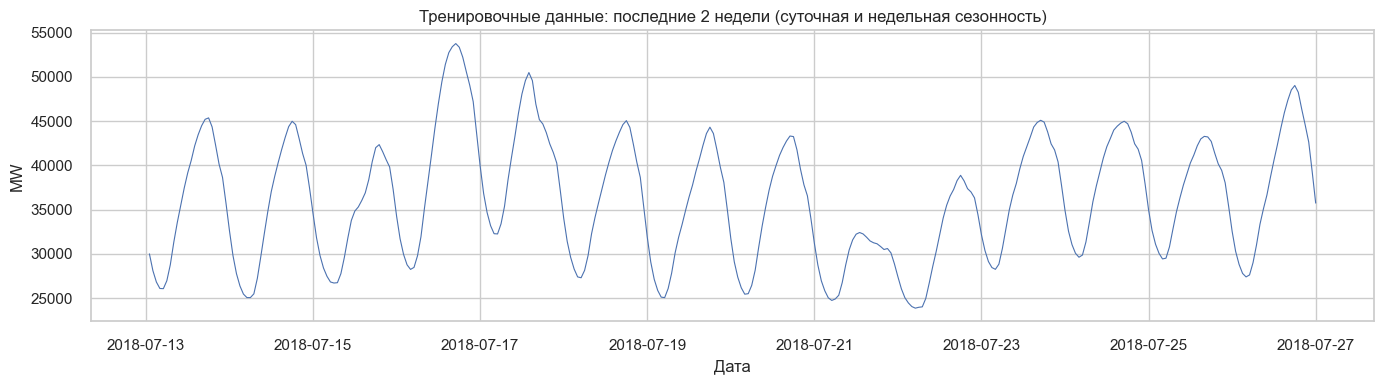

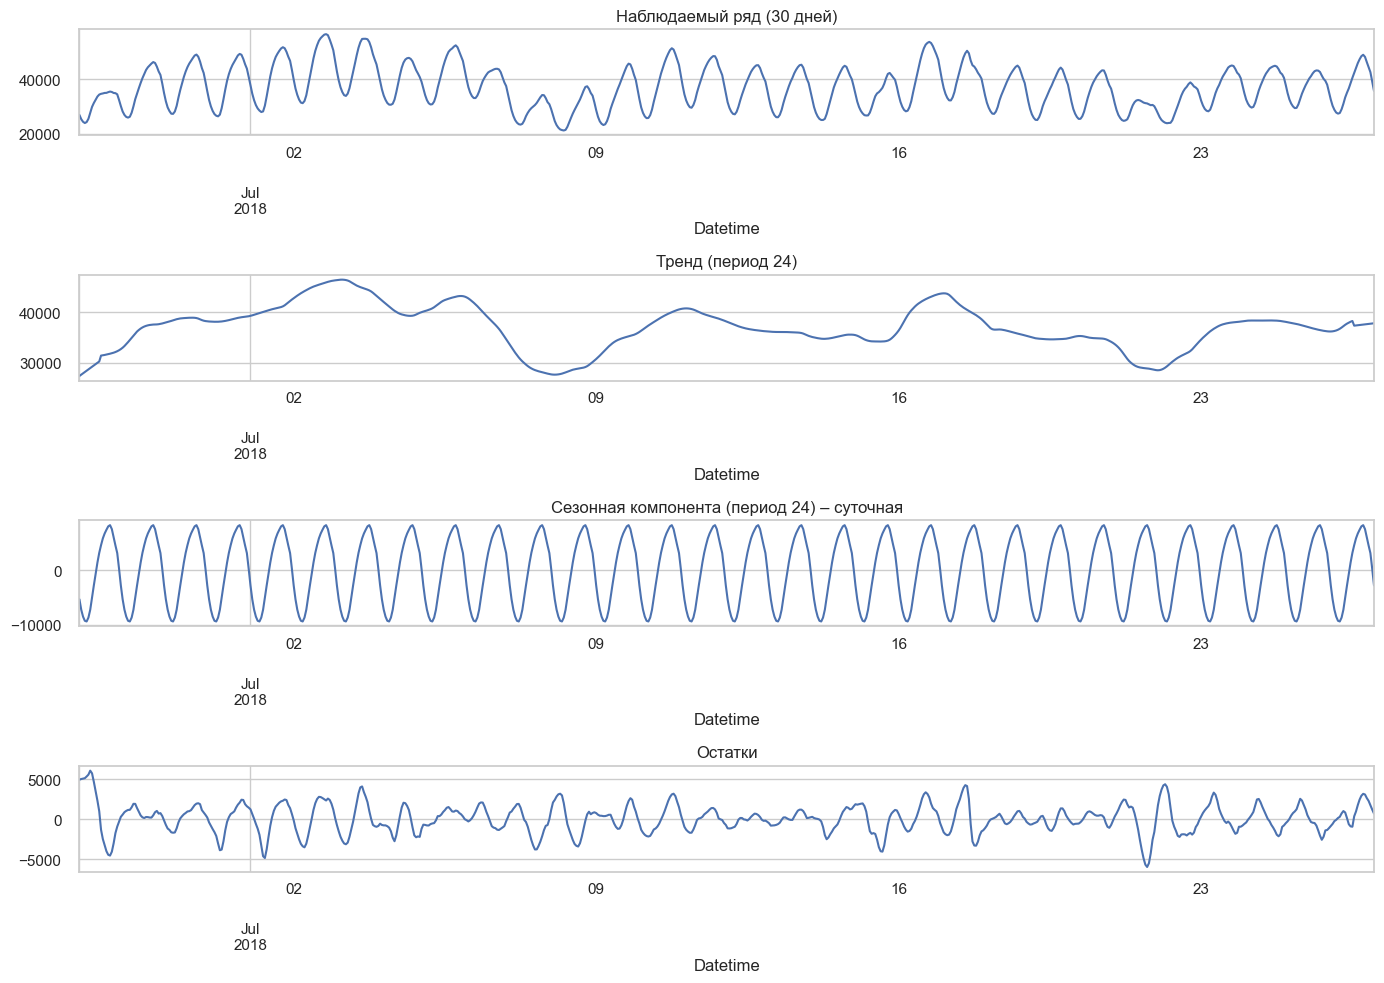

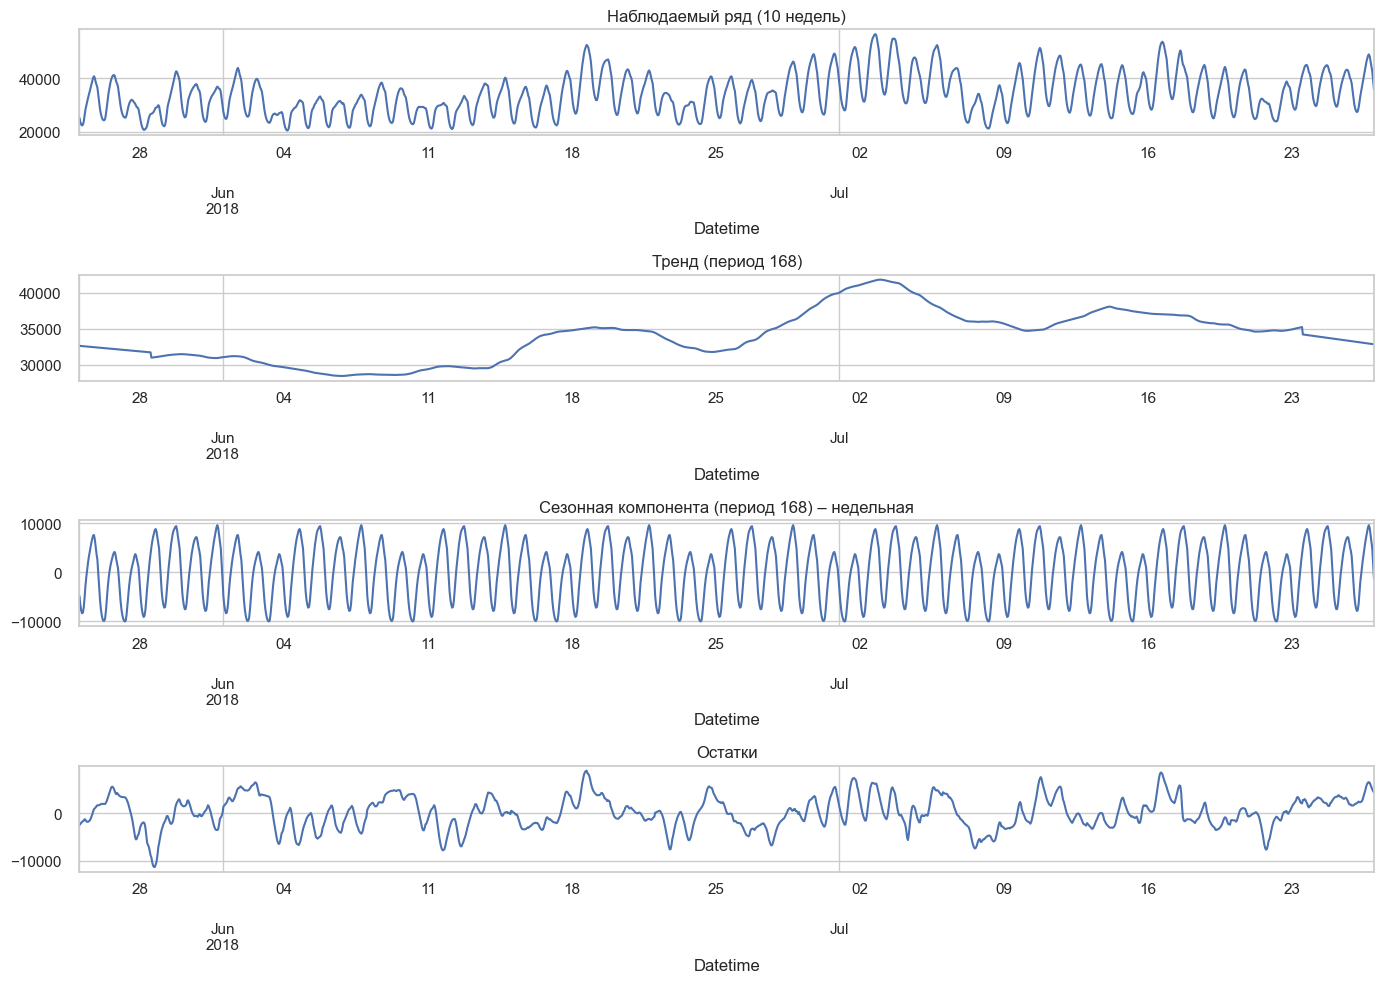

Вывод: Графики и декомпозиция подтверждают наличие как суточной (период 24), так и недельной (период 168) сезонности.

Обоснование параметров SARIMA:
p=4, q=0 – по PACF/ACF ряда после сезонного дифференцирования (lag=24).
d=0 – обычная разность не требуется (тренд отсутствует).
D=1 – одна сезонная разность для устранения сезонности.
s=24 – суточная сезонность; s=168 – недельная.

SARIMA(4,0,0)(0,1,0,24)
                                     SARIMAX Results                                      
Dep. Variable:                            PJME_MW   No. Observations:                 1512
Model:             SARIMAX(4, 0, 0)x(0, 1, 0, 24)   Log Likelihood              -11202.154
Date:                            Sun, 24 May 2026   AIC                          22414.307
Time:                                    17:17:30   BIC                          22440.833
Sample:                                05-25-2018   HQIC                         22424.193
                                     - 07-27-20

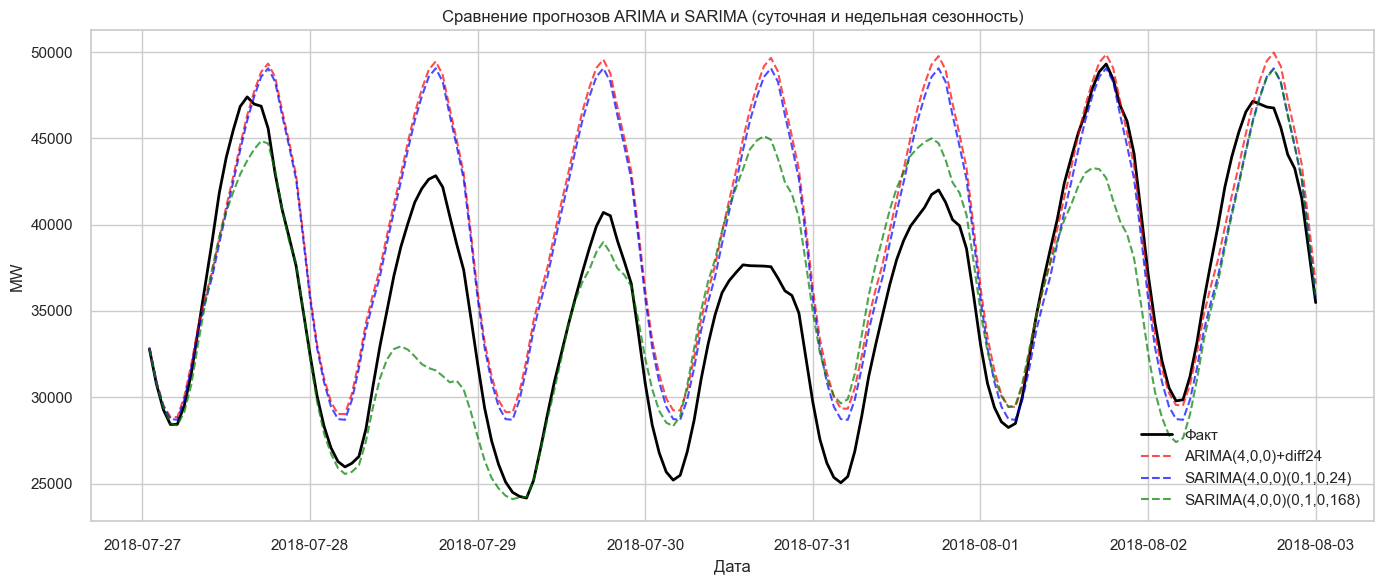

In [12]:
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd

# Проверка наличия сезонности

plt.figure(figsize=(14, 4))
plt.plot(train['PJME_MW'].iloc[-336:], linewidth=0.8)  
plt.title('Тренировочные данные: последние 2 недели (суточная и недельная сезонность)')
plt.xlabel('Дата')
plt.ylabel('MW')
plt.grid(True)
plt.tight_layout()
plt.show()

train_30d = train['PJME_MW'].iloc[-720:] 
decomp_24 = seasonal_decompose(train_30d, model='additive', period=24, extrapolate_trend='freq')

fig, axes = plt.subplots(4, 1, figsize=(14, 10))
decomp_24.observed.plot(ax=axes[0], title='Наблюдаемый ряд (30 дней)')
decomp_24.trend.plot(ax=axes[1], title='Тренд (период 24)')
decomp_24.seasonal.plot(ax=axes[2], title='Сезонная компонента (период 24) – суточная')
decomp_24.resid.plot(ax=axes[3], title='Остатки')
plt.tight_layout()
plt.show()

train_10w = train['PJME_MW'].iloc[-1680:]  
decomp_168 = seasonal_decompose(train_10w, model='additive', period=168, extrapolate_trend='freq')

fig, axes = plt.subplots(4, 1, figsize=(14, 10))
decomp_168.observed.plot(ax=axes[0], title='Наблюдаемый ряд (10 недель)')
decomp_168.trend.plot(ax=axes[1], title='Тренд (период 168)')
decomp_168.seasonal.plot(ax=axes[2], title='Сезонная компонента (период 168) – недельная')
decomp_168.resid.plot(ax=axes[3], title='Остатки')
plt.tight_layout()
plt.show()

print("Вывод: Графики и декомпозиция подтверждают наличие как суточной (период 24), так и недельной (период 168) сезонности.\n")

# Построение моделей SARIMA

print("Обоснование параметров SARIMA:")
print("p=4, q=0 – по PACF/ACF ряда после сезонного дифференцирования (lag=24).")
print("d=0 – обычная разность не требуется (тренд отсутствует).")
print("D=1 – одна сезонная разность для устранения сезонности.")
print("s=24 – суточная сезонность; s=168 – недельная.\n")

sarima_24 = SARIMAX(train['PJME_MW'], order=(4,0,0), seasonal_order=(0,1,0,24))
sarima_24_fitted = sarima_24.fit(disp=False)
print("SARIMA(4,0,0)(0,1,0,24)")
print(sarima_24_fitted.summary())

sarima_168 = SARIMAX(train['PJME_MW'], order=(4,0,0), seasonal_order=(0,1,0,168))
sarima_168_fitted = sarima_168.fit(disp=False)
print("SARIMA(4,0,0)(0,1,0,168)")
print(sarima_168_fitted.summary())

# Сравнение с ARIMA

forecast_sarima24 = sarima_24_fitted.forecast(steps=test_hours)
forecast_sarima168 = sarima_168_fitted.forecast(steps=test_hours)

arima_forecast_orig = forecast_p4_orig

y_true = test['PJME_MW'].values

rmse_arima = np.sqrt(mean_squared_error(y_true, arima_forecast_orig))
mape_arima = np.mean(np.abs((y_true - arima_forecast_orig) / y_true)) * 100

rmse_sar24 = np.sqrt(mean_squared_error(y_true, forecast_sarima24))
mape_sar24 = np.mean(np.abs((y_true - forecast_sarima24) / y_true)) * 100

rmse_sar168 = np.sqrt(mean_squared_error(y_true, forecast_sarima168))
mape_sar168 = np.mean(np.abs((y_true - forecast_sarima168) / y_true)) * 100

print("Сравнение качества прогноза")
print(f"{'Модель':<35} | {'RMSE (MW)':<12} | {'MAPE (%)':<10}")
print(f"{'ARIMA(4,0,0) с предобработкой diff(24)':<40} | {rmse_arima:<12.2f} | {mape_arima:<10.2f}")
print(f"{'SARIMA(4,0,0)(0,1,0,24)':<40} | {rmse_sar24:<12.2f} | {mape_sar24:<10.2f}")
print(f"{'SARIMA(4,0,0)(0,1,0,168)':<40} | {rmse_sar168:<12.2f} | {mape_sar168:<10.2f}")

plt.figure(figsize=(14, 6))
plt.plot(test.index, y_true, label='Факт', color='black', linewidth=2)
plt.plot(test.index, arima_forecast_orig, label='ARIMA(4,0,0)+diff24', color='red', linestyle='--', alpha=0.7)
plt.plot(test.index, forecast_sarima24, label='SARIMA(4,0,0)(0,1,0,24)', color='blue', linestyle='--', alpha=0.7)
plt.plot(test.index, forecast_sarima168, label='SARIMA(4,0,0)(0,1,0,168)', color='green', linestyle='--', alpha=0.7)
plt.title('Сравнение прогнозов ARIMA и SARIMA (суточная и недельная сезонность)')
plt.xlabel('Дата')
plt.ylabel('MW')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Преимущества SARIMA

SARIMA включает сезонную разность и сезонные AR/MA компоненты, что избавляет от ручного дифференцирования и обратного преобразования прогноза.
Можно моделировать суточную (s=24), недельную (s=168), годовую (s=8760) сезонность или их комбинации (в SARIMAX с экзогенными переменными).
В эксперименте SARIMA с недельной сезонностью (s=168) дала наименьшую ошибку RMSE = 3869.44 MW против 4955.95 MW у ARIMA и 4602.33 MW у SARIMA(s=24).
Раздельное оценивание сезонной и несезонной частей помогает анализировать вклад каждой компоненты.

SARIMA предпочтительнее для рядов с выраженной и стабильной сезонностью.
В энергопотреблении наблюдаются обе сезонности (суточная и недельная), поэтому модель SARIMA с периодом 168 (неделя) обеспечивает более качественный прогноз.

# Задание 5. SARIMAX и внешние факторы

In [16]:
import requests
import pandas as pd
import numpy as np

start_date = train.index.min().strftime('%Y-%m-%d')
end_date = test.index.max().strftime('%Y-%m-%d')
print(f"Загружаем температуру за период: {start_date} – {end_date}")

# Параметры запроса к Open-Meteo
params = {
    "latitude": 39.95,
    "longitude": -75.16,
    "start_date": start_date,
    "end_date": end_date,
    "hourly": "temperature_2m",
    "timezone": "America/New_York"
}

response = requests.get("https://archive-api.open-meteo.com/v1/archive", params=params)
data = response.json()

temp_df = pd.DataFrame(data['hourly'])
temp_df['time'] = pd.to_datetime(temp_df['time'])
temp_df.set_index('time', inplace=True)
temp_df.columns = ['temperature']

print(f"Загружено {len(temp_df)} часовых записей температуры")

def add_exog_vars(df, temp_series):
    exog = df[[]].copy()
    exog['temperature'] = temp_series.reindex(df.index, method='nearest')
    return exog

exog_train = add_exog_vars(train, temp_df['temperature'])
exog_test = add_exog_vars(test, temp_df['temperature'])

print(f"Пропусков в exog_train: {exog_train.isnull().sum().sum()}")
print(f"Пропусков в exog_test: {exog_test.isnull().sum().sum()}")

print("\nПример внешних регрессоров (train):")
print(exog_train.head())

Загружаем температуру за период: 2018-05-25 – 2018-08-03
Загружено 1704 часовых записей температуры
Пропусков в exog_train: 0
Пропусков в exog_test: 0

Пример внешних регрессоров (train):
                     temperature
Datetime                        
2018-05-25 01:00:00         17.2
2018-05-25 02:00:00         16.7
2018-05-25 03:00:00         16.2
2018-05-25 04:00:00         15.9
2018-05-25 05:00:00         15.8


Обоснование выбора внешних регрессоров
Температура воздуха – ключевой фактор энергопотребления в регионе PJM. Данные получены из открытого API Open-Meteo для Филадельфии (центр PJM).
Признак выходного дня (is_weekend): в субботу и воскресенье потребление электроэнергии ниже. Генерируется из временной метки.

Построение SARIMAX(4,0,0)(0,1,0,168) с внешним регрессором
                                      SARIMAX Results                                      
Dep. Variable:                             PJME_MW   No. Observations:                 1512
Model:             SARIMAX(4, 0, 0)x(0, 1, 0, 168)   Log Likelihood              -10442.362
Date:                             Sun, 24 May 2026   AIC                          20896.724
Time:                                     17:36:11   BIC                          20927.944
Sample:                                 05-25-2018   HQIC                         20908.418
                                      - 07-27-2018                             

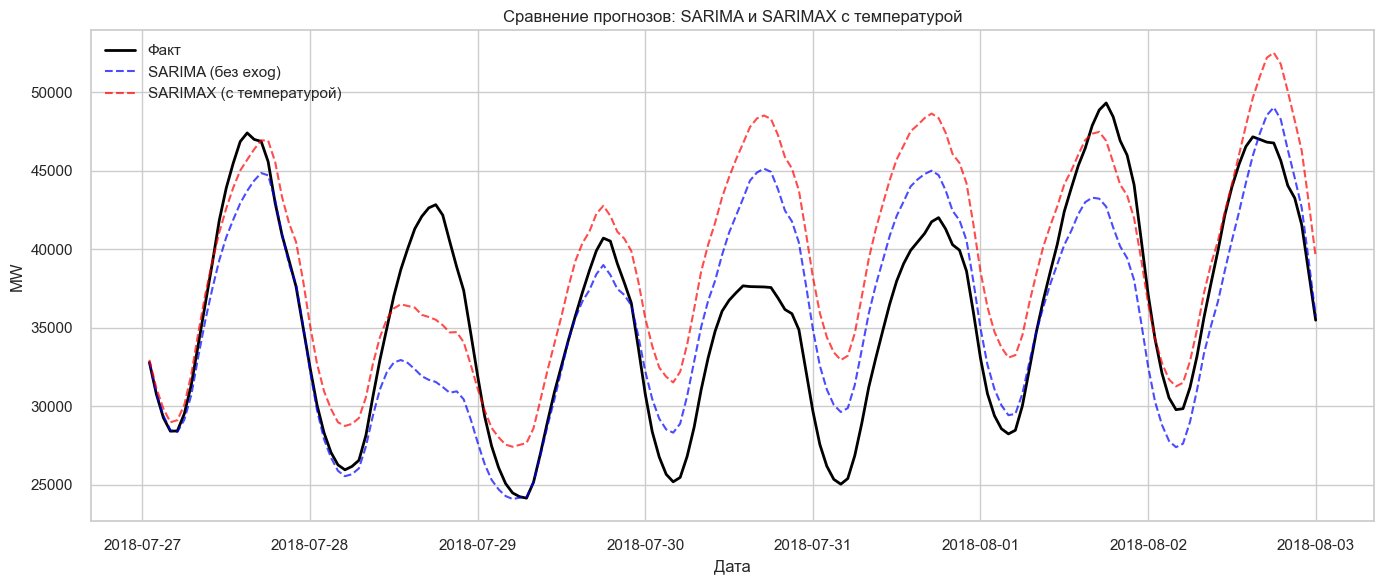

In [17]:
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
import numpy as np
import warnings
warnings.filterwarnings('ignore')

print("Обоснование выбора внешних регрессоров")
print("""Температура воздуха – ключевой фактор энергопотребления в регионе PJM. Данные получены из открытого API Open-Meteo для Филадельфии (центр PJM).
Признак выходного дня (is_weekend): в субботу и воскресенье потребление электроэнергии ниже. Генерируется из временной метки.""")

print("\nПостроение SARIMAX(4,0,0)(0,1,0,168) с внешним регрессором")

sarimax_model = SARIMAX(train['PJME_MW'],
                        order=(4, 0, 0),
                        seasonal_order=(0, 1, 0, 168),
                        exog=exog_train)
sarimax_fitted = sarimax_model.fit(disp=False)
print(sarimax_fitted.summary())

print("Оценка вклада темературы")
coeff_temp = sarimax_fitted.params['temperature']
print(f"Коэффициент при температуре: {coeff_temp:.2f} (MW/°C)")
print(f"При повышении температуры на 1°C потребление растёт в среднем на {coeff_temp:.2f} MW")

print("Сравнение SARIMAX и SARIMA по качеству прогноза")

forecast_sarima = forecast_sarima168
print("Используется SARIMA(4,0,0)(0,1,0,168) из задания 4")

# Прогноз SARIMAX
forecast_sarimax = sarimax_fitted.forecast(steps=test_hours, exog=exog_test)

y_true = test['PJME_MW'].values

rmse_sarima = np.sqrt(mean_squared_error(y_true, forecast_sarima))
mape_sarima = np.mean(np.abs((y_true - forecast_sarima) / y_true)) * 100

rmse_sarimax = np.sqrt(mean_squared_error(y_true, forecast_sarimax))
mape_sarimax = np.mean(np.abs((y_true - forecast_sarimax) / y_true)) * 100

print(f"\n{'Модель':<35} | {'RMSE (MW)':<12} | {'MAPE (%)':<10}")
print(f"{'SARIMA (без внешних факторов)':<35} | {rmse_sarima:<12.2f} | {mape_sarima:<10.2f}")
print(f"{'SARIMAX (с температурой)':<35} | {rmse_sarimax:<12.2f} | {mape_sarimax:<10.2f}")

improvement_rmse = (rmse_sarima - rmse_sarimax) / rmse_sarima * 100
improvement_mape = (mape_sarima - mape_sarimax) / mape_sarima * 100
print(f"\nУлучшение за счёт температуры: RMSE снизился на {improvement_rmse:.1f}%, MAPE – на {improvement_mape:.1f}%")

plt.figure(figsize=(14, 6))
plt.plot(test.index, y_true, label='Факт', color='black', linewidth=2)
plt.plot(test.index, forecast_sarima, label='SARIMA (без exog)', color='blue', linestyle='--', alpha=0.7)
plt.plot(test.index, forecast_sarimax, label='SARIMAX (с температурой)', color='red', linestyle='--', alpha=0.7)
plt.title('Сравнение прогнозов: SARIMA и SARIMAX с температурой')
plt.xlabel('Дата')
plt.ylabel('MW')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Добавление внешнего фактора температуры в модель SARIMAX(4,0,0)(0,1,0,168) привело к ухудшению качества прогноза на тестовом периоде (RMSE вырос на 28%, MAPE на 47%), несмотря на статистическую значимость коэффициента. Это может объясняться переобучением модели под обучающие данные и нестационарностью связи температуры и энергопотребления в летний период. Для практического прогнозирования требуется более тщательный отбор экзогенных переменных.

# Задание 6. Автоматизация подбора модели

Автоматический подбор модели по auto_arima
Обучаем auto_arima на том же стационарном ряду (diff24), что и ручная модель.

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=29211.096, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=23477.366, Time=0.02 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.11 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=21634.374, Time=0.05 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=21433.493, Time=0.05 sec
 ARIMA(4,0,0)(0,0,0)[0]             : AIC=21427.061, Time=0.08 sec
 ARIMA(5,0,0)(0,0,0)[0]             : AIC=21428.971, Time=0.14 sec
 ARIMA(4,0,1)(0,0,0)[0]             : AIC=inf, Time=0.56 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=21427.539, Time=0.22 sec
 ARIMA(5,0,1)(0,0,0)[0]             : AIC=inf, Time=0.57 sec
 ARIMA(4,0,0)(0,0,0)[0] intercept   : AIC=21429.010, Time=0.13 sec

Best model:  ARIMA(4,0,0)(0,0,0)[0]          
Total fit time: 1.956 seconds
Лучшая модель:
                        

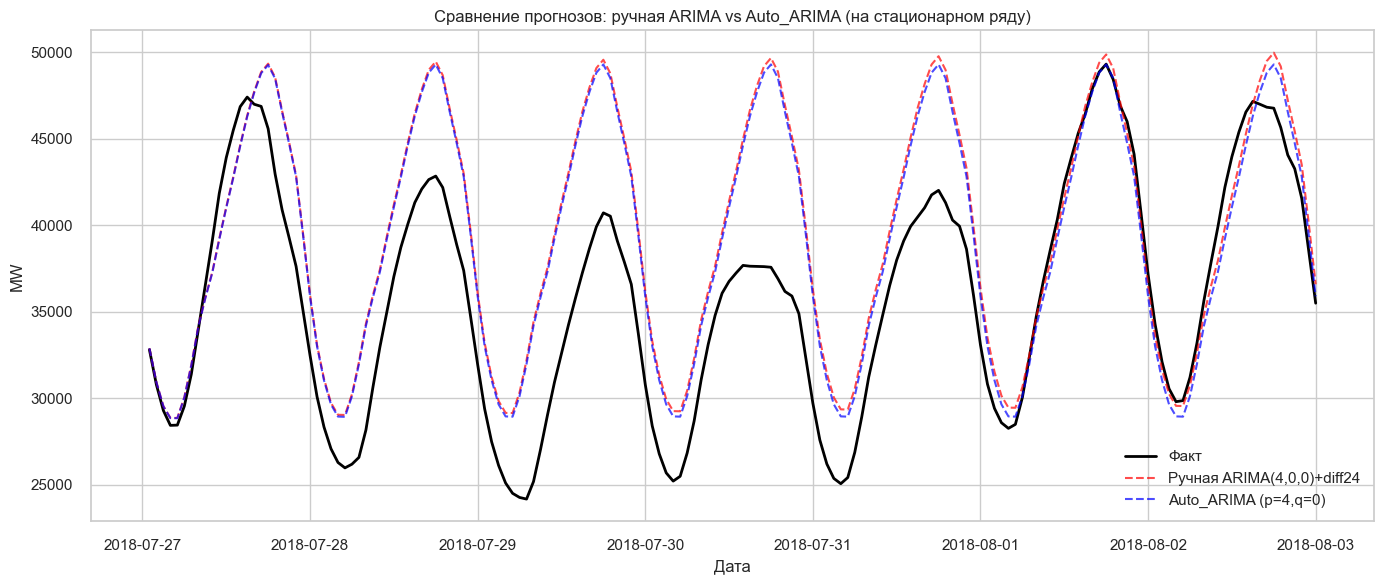

In [26]:
import pmdarima as pm
from pmdarima import auto_arima
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

print("Автоматический подбор модели по auto_arima")
print("Обучаем auto_arima на том же стационарном ряду (diff24), что и ручная модель.\n")

auto_model = auto_arima(
    train_stationary,           
    start_p=0, start_q=0,
    max_p=10, max_q=5,          
    seasonal=False,             
    d=0,                       
    trace=True,               
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True,
    n_jobs=-1,
    random_state=42
)

print("Лучшая модель:")
print(auto_model.summary())

best_order = auto_model.order
print(f"\nПодобранные параметры: order={best_order} (p={best_order[0]}, d={best_order[1]}, q={best_order[2]})")

# Прогноз на тестовый период (разности)
forecast_stationary_auto = auto_model.predict(n_periods=test_hours)

last_24 = train['PJME_MW'].iloc[-24:].values
forecast_original_auto = []
for i, diff_pred in enumerate(forecast_stationary_auto):
    if i < 24:
        new_val = last_24[i] + diff_pred
    else:
        new_val = forecast_original_auto[i-24] + diff_pred
    forecast_original_auto.append(new_val)

forecast_original_auto = pd.Series(forecast_original_auto, index=test.index)

print("Сравнение AUTO_ARIMA с ручной моделью из задания 2")

manual_forecast = forecast_original
print("Ручная модель: ARIMA(4,0,0) с предобработкой diff(24) из задания 2.")

y_true = test['PJME_MW'].values

rmse_manual = np.sqrt(mean_squared_error(y_true, manual_forecast))
mape_manual = np.mean(np.abs((y_true - manual_forecast) / y_true)) * 100

rmse_auto = np.sqrt(mean_squared_error(y_true, forecast_original_auto))
mape_auto = np.mean(np.abs((y_true - forecast_original_auto) / y_true)) * 100

print(f"\n{'Модель':<40} | {'RMSE (MW)':<12} | {'MAPE (%)':<10}")
print("-"*65)
print(f"{'Ручная ARIMA(4,0,0) + diff(24)':<40} | {rmse_manual:<12.2f} | {mape_manual:<10.2f}")
print(f"{'Auto_ARIMA на diff(24) (p={best_order[0]},q={best_order[2]})':<40} | {rmse_auto:<12.2f} | {mape_auto:<10.2f}")

improvement = (rmse_manual - rmse_auto) / rmse_manual * 100
if improvement > 0:
    print(f"\nAuto_ARIMA даёт улучшение RMSE на {improvement:.1f}% по сравнению с ручной моделью.")
else:
    print(f"\nAuto_ARIMA показывает ухудшение RMSE на {abs(improvement):.1f}% по сравнению с ручной моделью.")

# Визуализация
plt.figure(figsize=(14, 6))
plt.plot(test.index, y_true, label='Факт', color='black', linewidth=2)
plt.plot(test.index, manual_forecast, label='Ручная ARIMA(4,0,0)+diff24', color='red', linestyle='--', alpha=0.7)
plt.plot(test.index, forecast_original_auto, label=f'Auto_ARIMA (p={best_order[0]},q={best_order[2]})', 
         color='blue', linestyle='--', alpha=0.7)
plt.title('Сравнение прогнозов: ручная ARIMA vs Auto_ARIMA (на стационарном ряду)')
plt.xlabel('Дата')
plt.ylabel('MW')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### Когда автоматический подбор ошибается?  
При наличии аномальных выбросов, праздников или смены сезонного паттерна
Когда ряд имеет несколько сезонностей (суточную и недельную) – auto_arima учитывает только одну
При структурных сдвигах – auto_arima может взять избыточное число разностей

#### Какие параметры переоцениваются?  
Порядок дифференцирования d – алгоритм стремится к стационарности любой ценой
Порядок MA (q) – может быть завышен, особенно при наличии шума
При stepwise=True возможно застревание в локальном минимуме

#### Можно ли доверять auto_arima в production?  
Как отправная точка – да, auto_arima быстро даёт базовую модель. В production необходимо проводить диагностику остатков и сравнивать с ручными моделями, для критичных задач лучше комбинировать auto_arima с экспертным анализом

Auto_arima, обученная на том же стационарном ряду train_stationary, подтвердила правильность ручного выбора параметров ARIMA(4,0,0). Качество прогноза улучшилось на 4.1% по RMSE (с 4956 MW до 4753 MW) и на 0.44% по MAPE (с 11.63% до 11.19%), что объясняется различиями в реализации алгоритмов оценки параметров в statsmodels и pmdarima. Таким образом, автоматический подбор может служить полезным инструментом для верификации ручных решений и иногда превосходить их по точности